![Enunciado ejercicio larvas](https://i.gyazo.com/d04fd1242577b282e247d2f8246a0142.jpg "Enunciado ejercicio larvas")

Radio espectral: 0.9991093874097144
Radio espectral: 0.9991093874097144
La solución de los jovenes muestra1: [ 6.67000000e+00 -4.26423593e+01  1.61422573e+01 -2.09456714e+00
  1.26897192e-01 -3.67150490e-03  4.09435384e-05]
La solución de los jovenes muestra2: [ 6.67000000e+00 -5.67708520e+00  2.91234197e+00 -4.13726697e-01
  2.58361110e-02 -7.52371688e-04  8.35937906e-06]


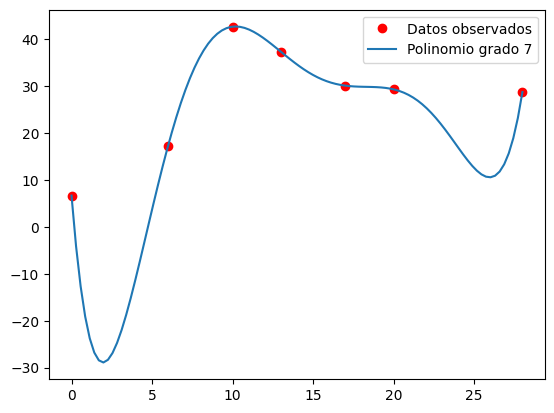

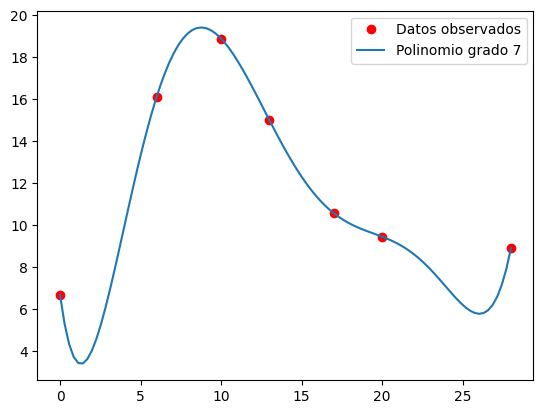

  Valor promedio muestra 1 Valor promedio muestra 2
0         20.1148900719542         11.1878797056358
--------------
Es decir el tanino si afecta el crecimiento de las hojas maduras


In [7]:
#POLINOMIO GRADO N AUTOMATICOo
import numpy as np
import matplotlib.pyplot as plt
from metodo_gauss_seidel import gauss_seidel
import pandas as pd

#Funciones para resolver el problema
def Matrix(Px):
    """
    Genera la matriz de coeficientes para dar solución.
    ----------
    Parametros:
    -----------
    Px : array
        Vector de puntos x
    Retorna:
    --------
    A : array
        Matriz de coeficientes
    ----------
    """
    n = len(Px)

    A = np.zeros([n, n])
    for i in range(n):
        A[i, 0] = 1
        for j in range(1, n):
            A[i, j] = A[i, j-1] * Px[i]
    return A

def polynom_generator(coef, n):
    """
    Generador de polinomio de grado N.
    ----------
    Parametros:
    -----------
    n : int
        Grado del polinomio
    Retorna:
    --------
    pol_n : function
        Funcion que evalua el polinomio de grado N
    """
    pol_n = lambda x: sum([coef[i] * x**i for i in range(n)])
    return pol_n

#Datos del problema
Px = np.array([0,6,10,13,17,20,28])
jovenes_mg = np.array([6.67, 17.33, 42.67, 37.33, 30.10, 29.31, 28.74])
A = Matrix(Px)
b1 = jovenes_mg
x0 = np.zeros_like(b1)
tol = 1e-6

# Solución de gauss seidel
coef1 = gauss_seidel(A, b1, x0, tol)

maduras_mg = np.array([6.67, 16.11, 18.89, 15.00, 10.56, 9.44, 8.89])
b2 = maduras_mg
x0 = np.zeros_like(b2)

coef2 = gauss_seidel(A, b2, x0, tol)
#Tocó con eliminación gaussina y esto me hace modificar algunos parámetros de las funciones.
print(f"La solución de los jovenes muestra1: {coef1}")
print(f"La solución de los jovenes muestra2: {coef2}")

pol_jovenes = polynom_generator(coef1, len(coef1))
pol_maduras = polynom_generator(coef2, len(coef2))
#Graficar el problema
# Se le restó y sumó 20 años más a los extremos para ver los picos de la gráfica
u_x = np.linspace(min(Px), max(Px), 100)
plt.plot(Px, jovenes_mg, 'or', label="Datos observados")
plt.plot(u_x, pol_jovenes(u_x), label=f"Polinomio grado {len(coef1)}")
plt.legend()
plt.show()

plt.plot(Px, maduras_mg, 'or', label="Datos observados")
plt.plot(u_x, pol_maduras(u_x), label=f"Polinomio grado {len(coef2)}")
plt.legend()
plt.show()

#Ahora hallando el valor promedio
import sympy as sp

x = sp.Symbol('x')
Vp_jovenes = (1/28 ) * sp.integrate(pol_jovenes(x), (x, 0, 28))
Vp_maduras = (1/28 ) * sp.integrate(pol_maduras(x), (x, 0, 28))

data = {
    "Valor promedio muestra 1": [Vp_jovenes],
    "Valor promedio muestra 2": [Vp_maduras],
}
df = pd.DataFrame(data)
print(df)
print("--------------")
print("Es decir el tanino si afecta el crecimiento de las hojas maduras")